<a href="https://colab.research.google.com/github/bernardenh-dabs/coffee-sales-analysis/blob/main/coffe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_excel('/content/sample_data/Raw Data coffe sales.xlsx')

df.head()

,Order ID,Order Date,Customer ID,Product ID,Quantity,Customer Name,Email,Country,Coffee Type,Roast Type,Size,Unit Price,Sales
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
import pandas as pd

file_path = "/content/sample_data/Raw Data coffe sales.xlsx"

xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

['orders', 'customers', 'products']


In [3]:
orders = pd.read_excel(file_path, sheet_name="orders")
customers = pd.read_excel(file_path, sheet_name="customers")
products = pd.read_excel(file_path, sheet_name="products")

In [4]:
for df in [orders, customers, products]:
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [5]:
print(products.columns)

Index(['product_id', 'coffee_type', 'roast_type', 'size', 'unit_price',
       'price_per_100g', 'profit'],
      dtype='object')


In [6]:
products.columns = products.columns.str.strip().str.lower().str.replace(" ", "_")


In [7]:
df = orders.merge(customers, on="customer_id", how="left") \
           .merge(products, on="product_id", how="left")

In [8]:
df.head()

,order_id,order_date,customer_id,product_id,quantity,customer_name_x,email_x,country_x,coffee_type_x,roast_type_x,...,city,country_y,postcode,loyalty_card,coffee_type_y,roast_type_y,size_y,unit_price_y,price_per_100g,profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,...,Paterson,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.5970
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,...,Paterson,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.9075
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,...,San Antonio,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.1655
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,...,Cill Airne,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.5125
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,...,Cill Airne,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.6491


In [9]:
df.isnull().sum()


,0
order_id,0
order_date,0
customer_id,0
product_id,0
quantity,0
customer_name_x,1000
email_x,1000
country_x,1000
coffee_type_x,1000
roast_type_x,1000


In [10]:
df.drop_duplicates()

,order_id,order_date,customer_id,product_id,quantity,customer_name_x,email_x,country_x,coffee_type_x,roast_type_x,...,city,country_y,postcode,loyalty_card,coffee_type_y,roast_type_y,size_y,unit_price_y,price_per_100g,profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,...,Paterson,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.59700
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,...,Paterson,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.90750
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,...,San Antonio,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.16550
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,...,Cill Airne,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.51250
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,...,Cill Airne,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.64910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,RLM-96511-467,2020-01-06,43014-53743-XK,R-L-2.5,1,NaN,NaN,NaN,NaN,NaN,...,Dallas,United States,75210,No,Rob,L,2.5,27.485,1.0994,1.64910
996,AEZ-13242-456,2022-05-04,62494-09113-RP,R-M-0.5,5,NaN,NaN,NaN,NaN,NaN,...,Fort Smith,United States,72905,No,Rob,M,0.5,5.970,1.1940,0.35820
997,UME-75640-698,2019-10-11,62494-09113-RP,A-M-0.5,4,NaN,NaN,NaN,NaN,NaN,...,Fort Smith,United States,72905,No,Ara,M,0.5,6.750,1.3500,0.60750
998,GJC-66474-557,2021-08-03,64965-78386-MY,A-D-1,1,NaN,NaN,NaN,NaN,NaN,...,Whittier,United States,90610,No,Ara,D,1.0,9.950,0.9950,0.89550


In [11]:
orders.head()
customers.head()
products.head()

,product_id,coffee_type,roast_type,size,unit_price,price_per_100g,profit
0,A-L-0.2,Ara,L,0.2,3.885,1.9425,0.34965
1,A-L-0.5,Ara,L,0.5,7.770,1.5540,0.69930
2,A-L-1,Ara,L,1.0,12.950,1.2950,1.16550
3,A-L-2.5,Ara,L,2.5,29.785,1.1914,2.68065
4,A-M-0.2,Ara,M,0.2,3.375,1.6875,0.30375


In [12]:
# ----------------------------
# MERGE TABLES (RELATIONAL MODEL)
# ----------------------------
df = orders.merge(customers, on="customer_id", how="left") \
           .merge(products, on="product_id", how="left")

# ----------------------------
# CHECK RESULT
# ----------------------------
print(df.shape)
df.head()

(1000, 27)


,order_id,order_date,customer_id,product_id,quantity,customer_name_x,email_x,country_x,coffee_type_x,roast_type_x,...,city,country_y,postcode,loyalty_card,coffee_type_y,roast_type_y,size_y,unit_price_y,price_per_100g,profit
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,...,Paterson,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.5970
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,...,Paterson,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.9075
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,...,San Antonio,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.1655
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,...,Cill Airne,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.5125
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,...,Cill Airne,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.6491


In [13]:
# Revenue
df['revenue'] = df['quantity'] * df['unit_price_y']

# Total Profit
if 'profit_y' in df.columns:
    df['total_profit'] = df['quantity'] * df['profit_y']

# Profit Margin
if 'revenue' in df.columns and 'total_profit' in df.columns:
    df['profit_margin'] = df['total_profit'] / df['revenue']

In [14]:
df.head()

,order_id,order_date,customer_id,product_id,quantity,customer_name_x,email_x,country_x,coffee_type_x,roast_type_x,...,country_y,postcode,loyalty_card,coffee_type_y,roast_type_y,size_y,unit_price_y,price_per_100g,profit,revenue
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,...,United States,7505,Yes,Rob,M,1.0,9.950,0.9950,0.5970,19.90
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,...,United States,7505,Yes,Exc,M,0.5,8.250,1.6500,0.9075,41.25
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,...,United States,78205,Yes,Ara,L,1.0,12.950,1.2950,1.1655,12.95
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,...,Ireland,N41,No,Exc,M,1.0,13.750,1.3750,1.5125,27.50
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,...,Ireland,N41,No,Rob,L,2.5,27.485,1.0994,1.6491,54.97


In [15]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.month_name()

In [16]:
customer_sales = df.groupby('customer_id')['revenue'].sum()

df['customer_segment'] = df['customer_id'].map(
    customer_sales.apply(
        lambda x: 'high value' if x > 500 else 'low value'
    )
)

In [17]:
# Example: Combine product info
df['product_category'] = df['coffee_type_y'] + "_" + df['roast_type_y']

In [18]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          1000 non-null   object        
 1   order_date        1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   object        
 3   product_id        1000 non-null   object        
 4   quantity          1000 non-null   int64         
 5   customer_name_x   0 non-null      float64       
 6   email_x           0 non-null      float64       
 7   country_x         0 non-null      float64       
 8   coffee_type_x     0 non-null      float64       
 9   roast_type_x      0 non-null      float64       
 10  size_x            0 non-null      float64       
 11  unit_price_x      0 non-null      float64       
 12  sales             0 non-null      float64       
 13  customer_name_y   1000 non-null   object        
 14  email_y           794 non

,order_id,order_date,customer_id,product_id,quantity,customer_name_x,email_x,country_x,coffee_type_x,roast_type_x,...,size_y,unit_price_y,price_per_100g,profit,revenue,year,month,month_name,customer_segment,product_category
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,NaN,NaN,NaN,NaN,NaN,...,1.0,9.950,0.9950,0.5970,19.90,2019,9,September,low value,Rob_M
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,NaN,NaN,NaN,NaN,NaN,...,0.5,8.250,1.6500,0.9075,41.25,2019,9,September,low value,Exc_M
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,NaN,NaN,NaN,NaN,NaN,...,1.0,12.950,1.2950,1.1655,12.95,2021,6,June,low value,Ara_L
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,NaN,NaN,NaN,NaN,NaN,...,1.0,13.750,1.3750,1.5125,27.50,2021,7,July,low value,Exc_M
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,NaN,NaN,NaN,NaN,NaN,...,2.5,27.485,1.0994,1.6491,54.97,2021,7,July,low value,Rob_L


In [19]:
# ----------------------------
# DROP USELESS (_x) COLUMNS
# ----------------------------
cols_to_drop = [col for col in df.columns if col.endswith('_x')]
df.drop(columns=cols_to_drop, inplace=True)

# ----------------------------
# REMOVE '_y' SUFFIX
# ----------------------------
df.columns = df.columns.str.replace('_y', '', regex=False)

# ----------------------------
# DROP COMPLETELY EMPTY COLUMNS (SAFETY)
# ----------------------------
df.dropna(axis=1, how='all', inplace=True)

# ----------------------------
# FINAL CHECK
# ----------------------------
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          1000 non-null   object        
 1   order_date        1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   object        
 3   product_id        1000 non-null   object        
 4   quantity          1000 non-null   int64         
 5   customer_name     1000 non-null   object        
 6   email             794 non-null    object        
 7   phone_number      865 non-null    object        
 8   address_line_1    1000 non-null   object        
 9   city              1000 non-null   object        
 10  country           1000 non-null   object        
 11  postcode          1000 non-null   object        
 12  loyalty_card      1000 non-null   object        
 13  coffee_type       1000 non-null   object        
 14  roast_type        1000 no

,order_id,order_date,customer_id,product_id,quantity,customer_name,email,phone_number,address_line_1,city,...,size,unit_price,price_per_100g,profit,revenue,year,month,month_name,customer_segment,product_category
0,QEV-37451-860,2019-09-05,17670-51384-MA,R-M-1,2,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,...,1.0,9.950,0.9950,0.5970,19.90,2019,9,September,low value,Rob_M
1,QEV-37451-860,2019-09-05,17670-51384-MA,E-M-0.5,5,Aloisia Allner,aallner0@lulu.com,+1 (862) 817-0124,57999 Pepper Wood Alley,Paterson,...,0.5,8.250,1.6500,0.9075,41.25,2019,9,September,low value,Exc_M
2,FAA-43335-268,2021-06-17,21125-22134-PX,A-L-1,1,Jami Redholes,jredholes2@tmall.com,+1 (210) 986-6806,5214 Bartillon Park,San Antonio,...,1.0,12.950,1.2950,1.1655,12.95,2021,6,June,low value,Ara_L
3,KAC-83089-793,2021-07-15,23806-46781-OU,E-M-1,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,...,1.0,13.750,1.3750,1.5125,27.50,2021,7,July,low value,Exc_M
4,KAC-83089-793,2021-07-15,23806-46781-OU,R-L-2.5,2,Christoffer O' Shea,NaN,+353 (698) 362-9201,38980 Manitowish Junction,Cill Airne,...,2.5,27.485,1.0994,1.6491,54.97,2021,7,July,low value,Rob_L


In [20]:
# Reorder columns (nice for analysis)
df = df[[
    'order_id','order_date','customer_id','customer_name','country',
    'product_id','coffee_type','roast_type','size',
    'quantity','unit_price','revenue','profit',
    'year','month','month_name','customer_segment'
]]

In [21]:
df.to_csv("/content/cleaned_coffee_sales.csv", index=False)

In [22]:
df.head()

,order_id,order_date,customer_id,customer_name,country,product_id,coffee_type,roast_type,size,quantity,unit_price,revenue,profit,year,month,month_name,customer_segment
0,QEV-37451-860,2019-09-05,17670-51384-MA,Aloisia Allner,United States,R-M-1,Rob,M,1.0,2,9.950,19.90,0.5970,2019,9,September,low value
1,QEV-37451-860,2019-09-05,17670-51384-MA,Aloisia Allner,United States,E-M-0.5,Exc,M,0.5,5,8.250,41.25,0.9075,2019,9,September,low value
2,FAA-43335-268,2021-06-17,21125-22134-PX,Jami Redholes,United States,A-L-1,Ara,L,1.0,1,12.950,12.95,1.1655,2021,6,June,low value
3,KAC-83089-793,2021-07-15,23806-46781-OU,Christoffer O' Shea,Ireland,E-M-1,Exc,M,1.0,2,13.750,27.50,1.5125,2021,7,July,low value
4,KAC-83089-793,2021-07-15,23806-46781-OU,Christoffer O' Shea,Ireland,R-L-2.5,Rob,L,2.5,2,27.485,54.97,1.6491,2021,7,July,low value


In [23]:
# Check missing values
print(df.isnull().sum())

# Check duplicates
print("Duplicates:", df.duplicated().sum())

order_id            0
order_date          0
customer_id         0
customer_name       0
country             0
product_id          0
coffee_type         0
roast_type          0
size                0
quantity            0
unit_price          0
revenue             0
profit              0
year                0
month               0
month_name          0
customer_segment    0
dtype: int64
Duplicates: 0


In [24]:
print("Total Revenue:", df['revenue'].sum())
print("Total Profit:", df['profit'].sum())
print("Total Orders:", df['order_id'].nunique())

Total Revenue: 45134.255
Total Profit: 1301.37505
Total Orders: 957


In [25]:
df.groupby('coffee_type')['revenue'].sum().sort_values(ascending=False)

,revenue
coffee_type,
Exc,12306.440
Lib,12054.075
Ara,11768.495
Rob,9005.245


In [26]:
df.groupby('roast_type')['revenue'].sum().sort_values(ascending=False)

,revenue
roast_type,
L,17354.465
M,14600.475
D,13179.315


In [27]:
df.groupby('country')['revenue'].sum().sort_values(ascending=False)

,revenue
country,
United States,35638.885
Ireland,6696.865
United Kingdom,2798.505


In [28]:
df.groupby('customer_name')['revenue'].sum().nlargest(10)

,revenue
customer_name,
Allis Wilmore,317.070
Brenn Dundredge,307.045
Terri Farra,289.110
Nealson Cuttler,281.675
Don Flintiff,278.010
Derick Snow,251.125
Brice Romera,246.210
Alexa Sizey,218.730
Ailey Brash,206.600


In [29]:
df.groupby('month_name')['revenue'].sum()

,revenue
month_name,
April,4224.595
August,2326.900
December,3089.660
February,4138.205
January,3503.035
July,3982.915
June,4843.040
March,4795.775
May,3247.980


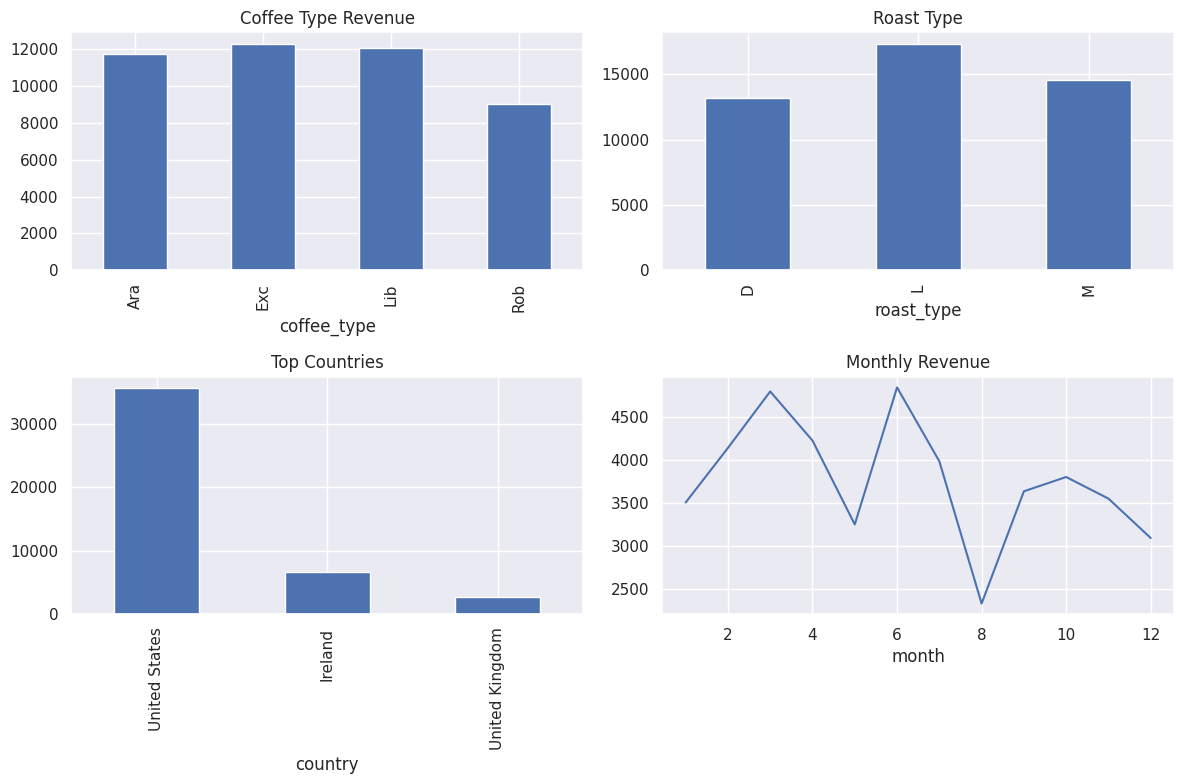

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

fig, axes = plt.subplots(2,2, figsize=(12,8))

# Revenue by coffee type
df.groupby('coffee_type')['revenue'].sum().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Coffee Type Revenue")

# Revenue by roast
df.groupby('roast_type')['revenue'].sum().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Roast Type")

# Top countries
df.groupby('country')['revenue'].sum().nlargest(5).plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Top Countries")

# Monthly trend
df.groupby('month')['revenue'].sum().plot(ax=axes[1,1])
axes[1,1].set_title("Monthly Revenue")

plt.tight_layout()
plt.show()

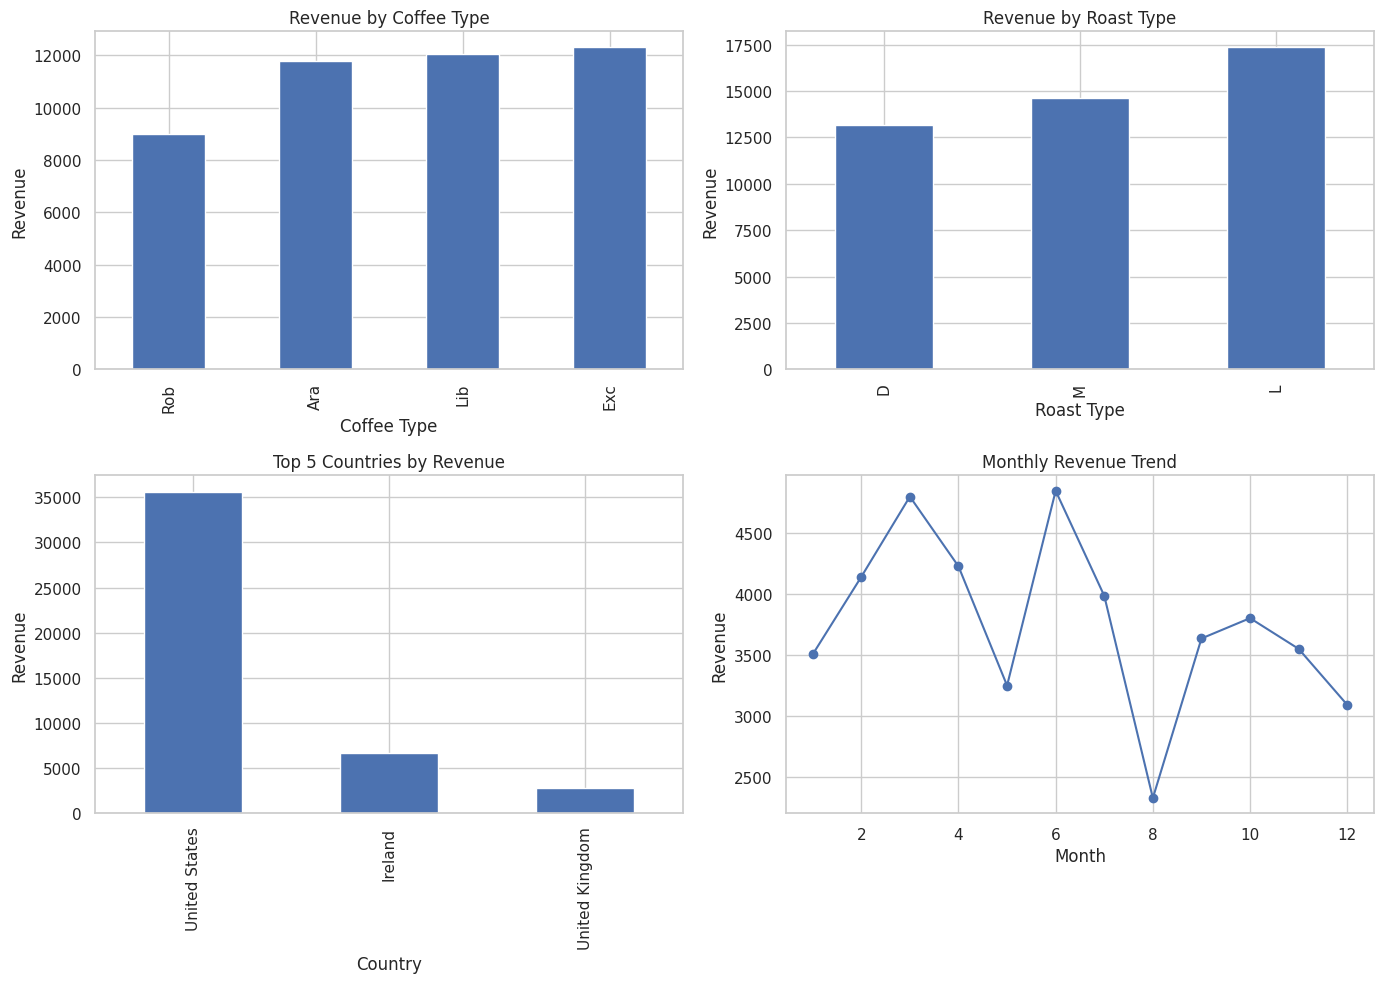

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue by coffee type (sorted)
coffee_rev = df.groupby('coffee_type')['revenue'].sum().sort_values()
coffee_rev.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Revenue by Coffee Type")
axes[0,0].set_xlabel("Coffee Type")
axes[0,0].set_ylabel("Revenue")

# 2. Revenue by roast type (sorted)
roast_rev = df.groupby('roast_type')['revenue'].sum().sort_values()
roast_rev.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Revenue by Roast Type")
axes[0,1].set_xlabel("Roast Type")
axes[0,1].set_ylabel("Revenue")

# 3. Top 5 countries
top_countries = df.groupby('country')['revenue'].sum().nlargest(5)
top_countries.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Top 5 Countries by Revenue")
axes[1,0].set_xlabel("Country")
axes[1,0].set_ylabel("Revenue")

# 4. Monthly trend (sorted)
monthly_rev = df.groupby('month')['revenue'].sum().sort_index()
monthly_rev.plot(marker='o', ax=axes[1,1])
axes[1,1].set_title("Monthly Revenue Trend")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Revenue")

plt.tight_layout()
plt.show()

Insight: Identify which coffee type generates the most revenue to prioritize production and marketing.
Insight: Helps determine customer taste preference and optimize inventory.
Insight: Focus marketing and distribution strategies on top-performing regions.
Insight: Detect seasonality trends for better demand forecasting.


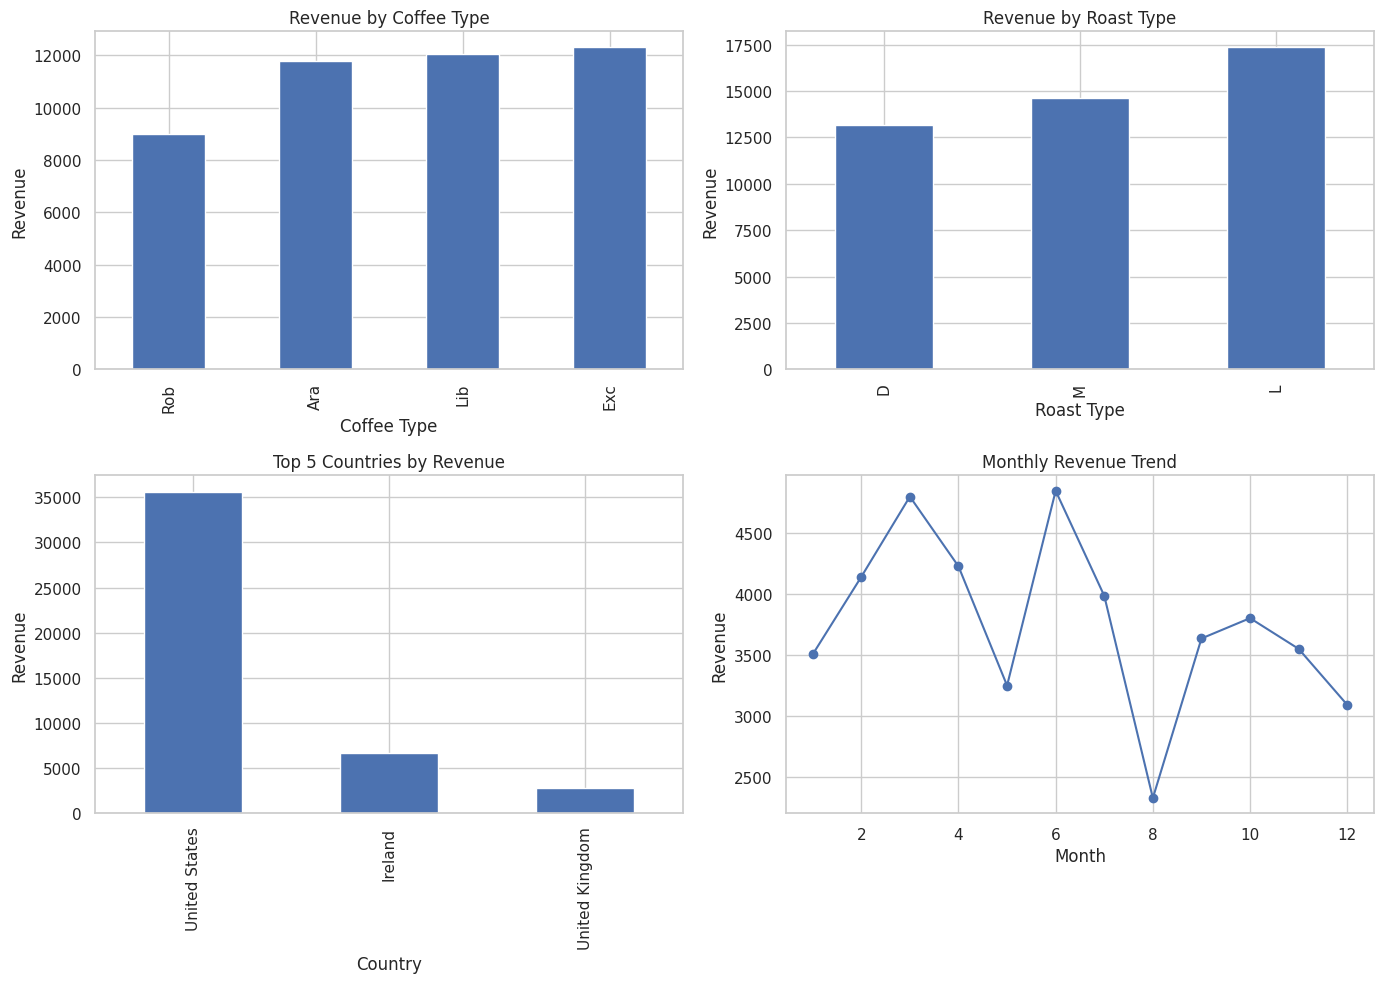

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue by coffee type
coffee_rev = df.groupby('coffee_type')['revenue'].sum().sort_values()
coffee_rev.plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Revenue by Coffee Type")
axes[0,0].set_xlabel("Coffee Type")
axes[0,0].set_ylabel("Revenue")

# Insight
print("Insight: Identify which coffee type generates the most revenue to prioritize production and marketing.")

# 2. Revenue by roast type
roast_rev = df.groupby('roast_type')['revenue'].sum().sort_values()
roast_rev.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Revenue by Roast Type")
axes[0,1].set_xlabel("Roast Type")
axes[0,1].set_ylabel("Revenue")

print("Insight: Helps determine customer taste preference and optimize inventory.")

# 3. Top 5 countries
top_countries = df.groupby('country')['revenue'].sum().nlargest(5)
top_countries.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Top 5 Countries by Revenue")
axes[1,0].set_xlabel("Country")
axes[1,0].set_ylabel("Revenue")

print("Insight: Focus marketing and distribution strategies on top-performing regions.")

# 4. Monthly trend
monthly_rev = df.groupby('month')['revenue'].sum().sort_index()
monthly_rev.plot(marker='o', ax=axes[1,1])
axes[1,1].set_title("Monthly Revenue Trend")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Revenue")

print("Insight: Detect seasonality trends for better demand forecasting.")

plt.tight_layout()
plt.show()

In [33]:
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height():.0f}',
                      (p.get_x()+0.2, p.get_height()+100))

In [34]:
df['month_name'] = df['order_date'].dt.strftime('%b')

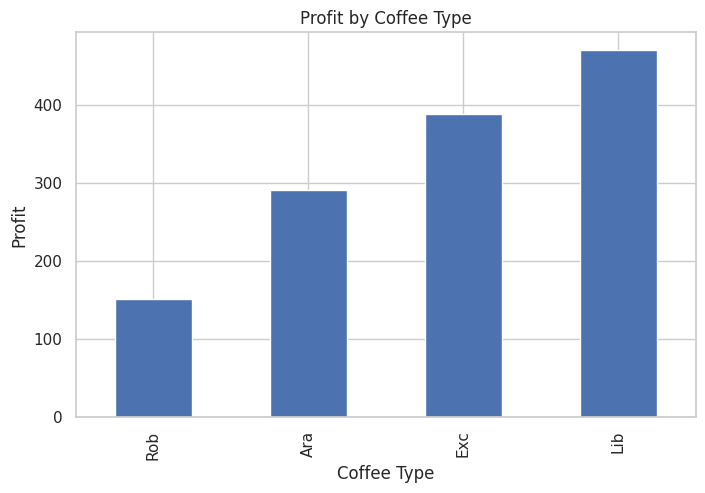

In [35]:
profit_by_coffee = df.groupby('coffee_type')['profit'].sum().sort_values()

plt.figure(figsize=(8,5))
profit_by_coffee.plot(kind='bar')
plt.title("Profit by Coffee Type")
plt.xlabel("Coffee Type")
plt.ylabel("Profit")
plt.show()

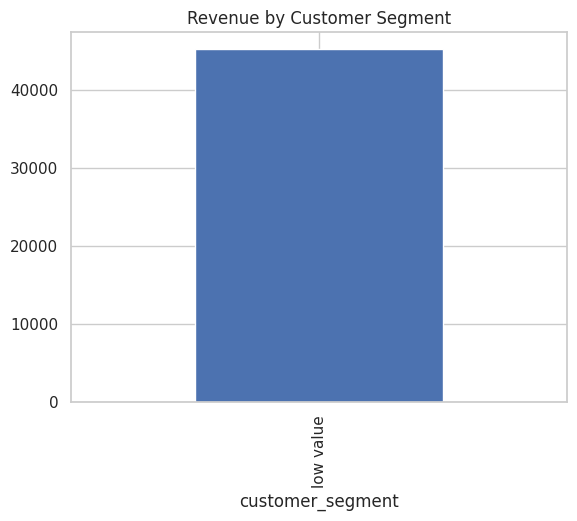

In [36]:
df.groupby('customer_segment')['revenue'].sum().plot(kind='bar')
plt.title("Revenue by Customer Segment")
plt.show()

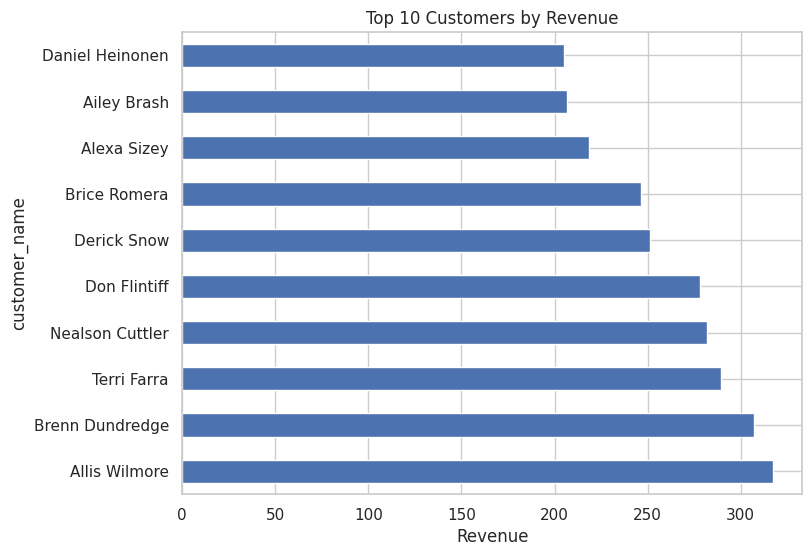

In [37]:
top_customers = df.groupby('customer_name')['revenue'].sum().nlargest(10)

top_customers.plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.show()

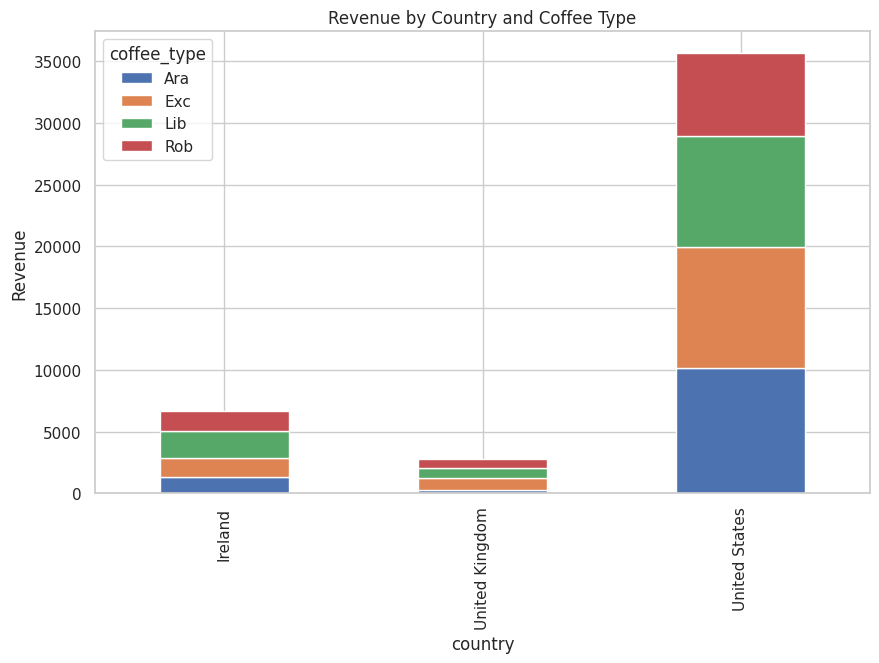

In [38]:
pivot = pd.pivot_table(df,
                       values='revenue',
                       index='country',
                       columns='coffee_type',
                       aggfunc='sum')

pivot.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Revenue by Country and Coffee Type")
plt.ylabel("Revenue")
plt.show()

In [39]:
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()

print("Revenue:", total_revenue)
print("Profit:", total_profit)
print("Orders:", total_orders)

Revenue: 45134.255
Profit: 1301.37505
Orders: 957


In [40]:
df['profit_margin'] = df['profit'] / df['revenue']

In [41]:
aov = df['revenue'].sum() / df['order_id'].nunique()

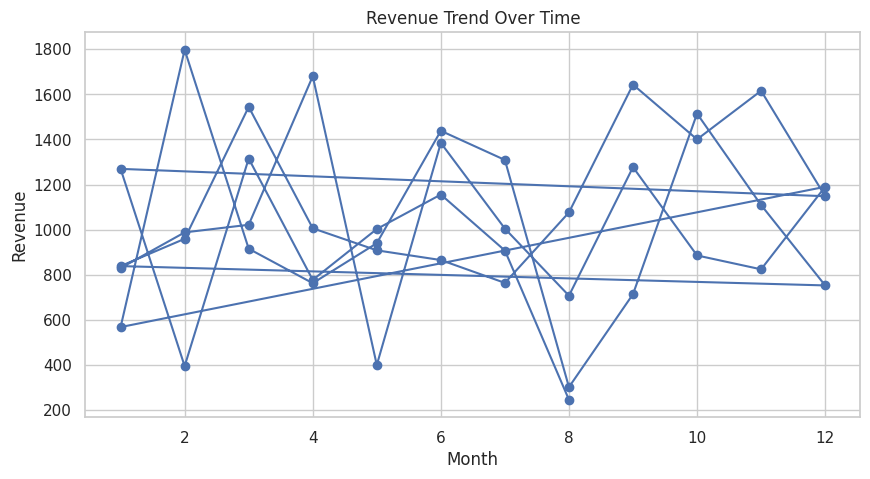

In [42]:
monthly = df.groupby(['year','month'])['revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly['month'], monthly['revenue'], marker='o')
plt.title("Revenue Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [43]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("coffee.db")

# Save the DataFrame to the SQLite database
df.to_sql("coffee_sales_clean", conn, if_exists="replace", index=False)

query = "SELECT * FROM coffee_sales_clean"
df = pd.read_sql(query, conn)

conn.close()

In [44]:
!pip install streamlit
import streamlit as st

st.title("Coffee Sales Dashboard")

country = st.selectbox("Select Country", df['country'].unique())

filtered = df[df['country'] == country]

st.bar_chart(filtered.groupby('coffee_type')['revenue'].sum())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 82.2 MB/s eta 0:00:00


2026-04-17 11:49:51.207 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:51.576 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-17 11:49:51.577 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:51.578 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:51.580 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:51.581 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:51.583 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:51.584 Thread 'MainThread': mi

DeltaGenerator()

In [45]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['revenue'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=6)
print(forecast)

1000    46.738824
1001    45.059333
1002    45.141416
1003    45.137404
1004    45.137600
1005    45.137591
Name: predicted_mean, dtype: float64


In [46]:
def load_data(path):
    import pandas as pd
    df = pd.read_csv(path)
    return df

In [47]:
def clean_data(df):
    df = df.drop_duplicates()
    df['order_date'] = pd.to_datetime(df['order_date'])
    # Removed the line below as 'delivery_date' column does not exist
    # df['delivery_time'] = (df['delivery_date'] - df['order_date']).dt.days
    df.fillna(0, inplace=True)
    return df

In [48]:
def feature_engineering(df):
    df['month'] = df['order_date'].dt.month
    df['year'] = df['order_date'].dt.year
    df['profit_margin'] = df['profit'] / df['revenue']
    return df

In [49]:
def analyze_data(df):
    summary = df.groupby('coffee_type')['revenue'].sum().sort_values(ascending=False)
    return summary

In [50]:
def save_output(df, path):
    df.to_csv(path, index=False)

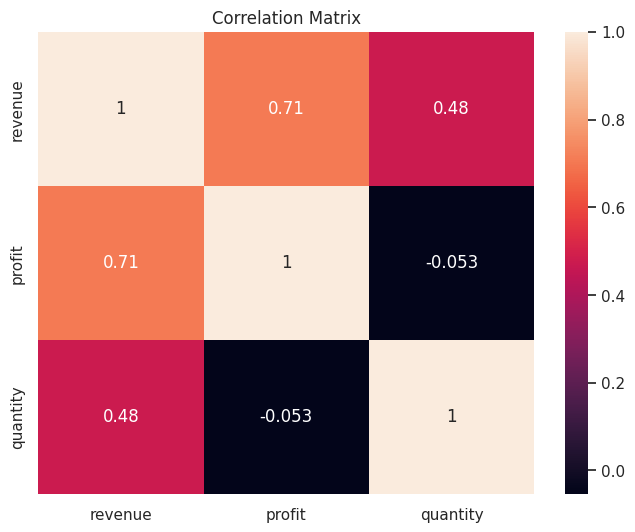

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[['revenue','profit','quantity']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

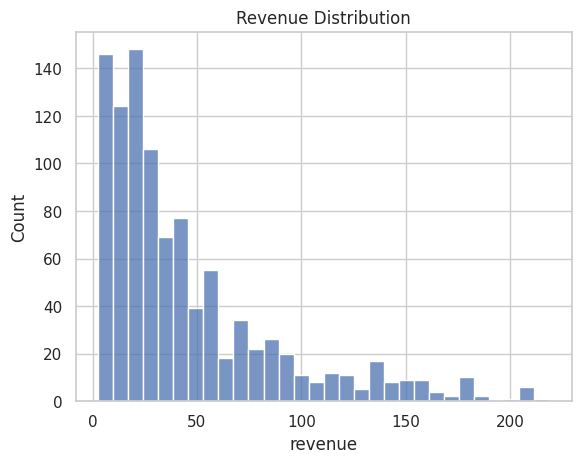

In [52]:
sns.histplot(df['revenue'], bins=30)
plt.title("Revenue Distribution")
plt.show()

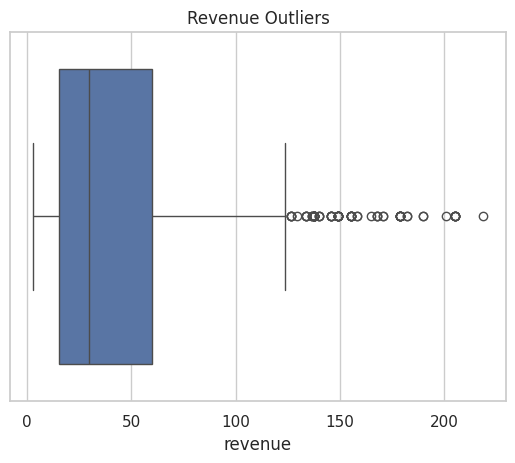

In [53]:
sns.boxplot(x=df['revenue'])
plt.title("Revenue Outliers")
plt.show()

In [54]:
from sklearn.model_selection import train_test_split

features = df[['quantity']]
target = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

In [55]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [56]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, predictions))

MAE: 29.225574304761604


In [57]:
# If 'order_date' is already the index, reset it to make it a column again.
# This makes the operation idempotent for repeated executions.
if df.index.name == 'order_date':
    df.reset_index(inplace=True)

# Now, 'order_date' is guaranteed to be a column.
# Convert 'order_date' to datetime and set it as the index.
df['order_date'] = pd.to_datetime(df['order_date'])
df.set_index('order_date', inplace=True)

# Perform the resampling
monthly = df['revenue'].resample('ME').sum()

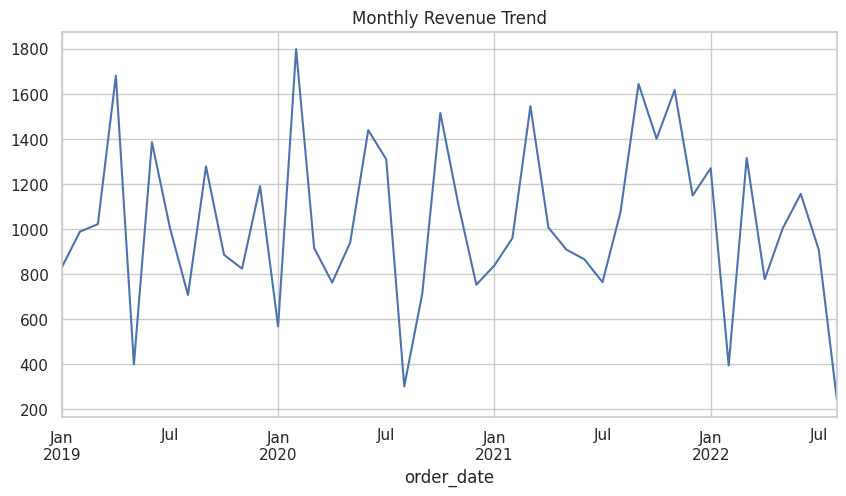

In [58]:
monthly.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

In [59]:
df.to_csv("dashboard_data.csv")

In [60]:
import logging

logging.basicConfig(level=logging.INFO)

logging.info("Data loaded successfully")

In [61]:
try:
    df = pd.read_csv("data.csv")
except Exception as e:
    print("Error loading data:", e)

Error loading data: [Errno 2] No such file or directory: 'data.csv'


In [62]:
import pandas as pd

df = pd.read_csv("/content/cleaned_coffee_sales.csv")
df.head()

,order_id,order_date,customer_id,customer_name,country,product_id,coffee_type,roast_type,size,quantity,unit_price,revenue,profit,year,month,month_name,customer_segment
0,QEV-37451-860,2019-09-05,17670-51384-MA,Aloisia Allner,United States,R-M-1,Rob,M,1.0,2,9.950,19.90,0.5970,2019,9,September,low value
1,QEV-37451-860,2019-09-05,17670-51384-MA,Aloisia Allner,United States,E-M-0.5,Exc,M,0.5,5,8.250,41.25,0.9075,2019,9,September,low value
2,FAA-43335-268,2021-06-17,21125-22134-PX,Jami Redholes,United States,A-L-1,Ara,L,1.0,1,12.950,12.95,1.1655,2021,6,June,low value
3,KAC-83089-793,2021-07-15,23806-46781-OU,Christoffer O' Shea,Ireland,E-M-1,Exc,M,1.0,2,13.750,27.50,1.5125,2021,7,July,low value
4,KAC-83089-793,2021-07-15,23806-46781-OU,Christoffer O' Shea,Ireland,R-L-2.5,Rob,L,2.5,2,27.485,54.97,1.6491,2021,7,July,low value


In [63]:
import pandas as pd
import os

def run_analysis():
    # Fix: Changed the file path to the existing cleaned_coffee_sales.csv
    df = pd.read_csv("/content/cleaned_coffee_sales.csv")

    # Ensure 'order_date' is datetime before proceeding, as it might be read as object from CSV
    df['order_date'] = pd.to_datetime(df['order_date'])

    # Clean
    df.drop_duplicates(inplace=True)

    # Feature Engineering
    df['month'] = df['order_date'].dt.month
    # Check if 'profit' and 'revenue' columns exist before calculating 'profit_margin'
    if 'profit' in df.columns and 'revenue' in df.columns:
        df['profit_margin'] = df['profit'] / df['revenue']
    else:
        print("Warning: 'profit' or 'revenue' columns not found. Skipping 'profit_margin' calculation.")

    # Analysis
    revenue_by_coffee = df.groupby('coffee_type')['revenue'].sum()

    print("Revenue by Coffee Type:\n", revenue_by_coffee)

    # Save
    # Create the 'outputs' directory if it doesn't exist
    os.makedirs("outputs", exist_ok=True)
    df.to_csv("outputs/cleaned_data.csv", index=False)

if __name__ == "__main__":
    run_analysis()

Revenue by Coffee Type:
 coffee_type
Ara    11768.495
Exc    12306.440
Lib    12054.075
Rob     9005.245
Name: revenue, dtype: float64


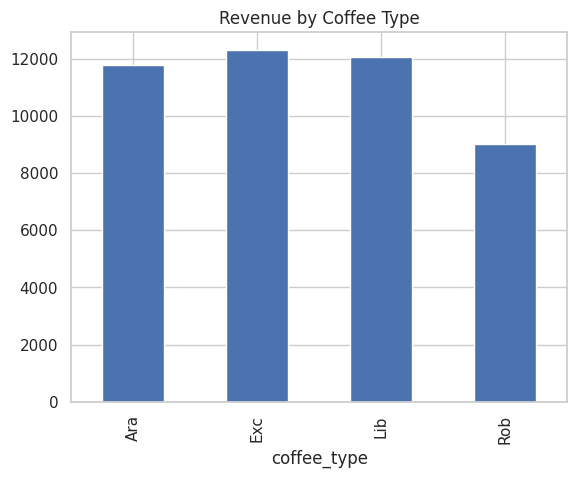

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/cleaned_data.csv")

df.groupby('coffee_type')['revenue'].sum().plot(kind='bar')
plt.title("Revenue by Coffee Type")
plt.show()

In [65]:
import pandas as pd
import os

def run_analysis():
    # Fix: Changed the file path to the existing cleaned_coffee_sales.csv
    df = pd.read_csv("/content/cleaned_coffee_sales.csv")

    # Ensure 'order_date' is datetime before proceeding, as it might be read as object from CSV
    df['order_date'] = pd.to_datetime(df['order_date'])

    # Clean
    df.drop_duplicates(inplace=True)

    # Feature Engineering
    df['month'] = df['order_date'].dt.month
    # Check if 'profit' and 'revenue' columns exist before calculating 'profit_margin'
    if 'profit' in df.columns and 'revenue' in df.columns:
        df['profit_margin'] = df['profit'] / df['revenue']
    else:
        print("Warning: 'profit' or 'revenue' columns not found. Skipping 'profit_margin' calculation.")

    # Analysis
    revenue_by_coffee = df.groupby('coffee_type')['revenue'].sum()

    print("Revenue by Coffee Type:\n", revenue_by_coffee)

    # Save
    # Create the 'outputs' directory if it doesn't exist
    os.makedirs("outputs", exist_ok=True)
    df.to_csv("outputs/cleaned_data.csv", index=False)

print("Running full pipeline...")
run_analysis()
print("Done!")

Running full pipeline...
Revenue by Coffee Type:
 coffee_type
Ara    11768.495
Exc    12306.440
Lib    12054.075
Rob     9005.245
Name: revenue, dtype: float64
Done!


In [66]:
def generate_insights(df):
    top_coffee = df.groupby('coffee_type')['revenue'].sum().idxmax()
    top_country = df.groupby('country')['revenue'].sum().idxmax()

    print(f"Top Coffee Type: {top_coffee}")
    print(f"Top Country: {top_country}")

In [67]:
summary = df.groupby('country')['revenue'].sum()

summary.to_csv("outputs/country_summary.csv")

In [68]:
import pandas as pd
import streamlit as st

df = pd.read_csv("outputs/cleaned_data.csv")

st.title("Coffee Analytics Dashboard")

coffee = st.selectbox("Select Coffee Type", df['coffee_type'].unique())

filtered = df[df['coffee_type'] == coffee]

st.write(filtered)
st.bar_chart(filtered.groupby('country')['revenue'].sum())

2026-04-17 11:49:59.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:59.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:59.641 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:59.649 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:59.657 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:59.661 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:59.665 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-17 11:49:59.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [69]:
DATA_PATH = "data/raw_data.csv"
CLEAN_DATA_PATH = "outputs/cleaned_data.csv"

In [70]:
import pandas as pd

# Define paths directly to avoid relative import issues
DATA_PATH = "/content/cleaned_coffee_sales.csv" # Using the previously cleaned data as input
CLEAN_DATA_PATH = "outputs/cleaned_data.csv"

def load_data():
    return pd.read_csv(DATA_PATH)

def clean_data(df):
    df = df.drop_duplicates()
    df['order_date'] = pd.to_datetime(df['order_date'])
    return df

def feature_engineering(df):
    df['month'] = df['order_date'].dt.month
    # Ensure 'profit' and 'revenue' columns exist before calculation
    if 'profit' in df.columns and 'revenue' in df.columns:
        df['profit_margin'] = df['profit'] / df['revenue']
    else:
        print("Warning: 'profit' or 'revenue' columns not found. Skipping 'profit_margin' calculation.")
    return df

def save_data(df):
    df.to_csv(CLEAN_DATA_PATH, index=False)

def run_pipeline():
    df = load_data()
    df = clean_data(df)
    df = feature_engineering(df)
    save_data(df)
    return df

In [71]:
def top_n(df, column, n=5):
    return df.sort_values(by=column, ascending=False).head(n)

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

def train_model(df):
    X = df[['quantity']]
    y = df['revenue']

    X_train, X_test, y_train, y_test = train_test_split(X, y)

    model = LinearRegression()
    model.fit(X_train, y_train)

    return model

In [73]:
def main():
    df = run_pipeline()

    model = train_model(df)

    print("Pipeline and model executed successfully!")

if __name__ == "__main__":
    main()

Pipeline and model executed successfully!


In [74]:
def test_load_data():
    df = load_data()
    assert df is not None
    assert len(df) > 0

In [75]:
import logging

logging.basicConfig(level=logging.INFO)

logging.info("Pipeline started")

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [77]:
import shutil

# The 'FileNotFoundError' indicates that '/content/your_notebook_name.ipynb' does not exist.
# You need to replace 'your_notebook_name.ipynb' with the actual filename of the notebook
# you wish to copy. For example, if your notebook is named 'MyAnalysis.ipynb',
# the path might be '/content/MyAnalysis.ipynb' or its path in Google Drive.
#
# If you are trying to save *this current notebook* to Google Drive, it's usually
# easier to use the 'File -> Save a copy in Drive' option in the Colab menu.

# shutil.copy('/content/your_notebook_name.ipynb',
#             '/content/drive/MyDrive/coffee_sales_analysis.ipynb')


In [78]:
import shutil

shutil.copy('/content/sample_data/Raw Data coffe sales.xlsx',
            '/content/drive/MyDrive/coffee_sales_analysis.ipynb')

'/content/drive/MyDrive/coffee_sales_analysis.ipynb'

### Step 1: Generate a GitHub Personal Access Token (PAT)

YouTo push to a private GitHub repository or when using 2FA, you need a Personal Access Token (PAT). If you don't have one, follow these steps:

1.  Go to your GitHub profile settings.
2.  Navigate to 'Developer settings' -> 'Personal access tokens' -> 'Tokens (classic)'.
3.  Click 'Generate new token' (classic).
4.  Give your token a descriptive name (e.g., "Colab_Access").
5.  Select the `repo` scope (this gives full control of private repositories).
6.  Click 'Generate token'.
7.  **IMPORTANT**: Copy the generated token immediately. You won't be able to see it again!

Once you have your PAT, you will use it in the next step to authenticate.

In [79]:
#@title ### Step 2: Configure Git and Clone your Repository

# Input your GitHub username and email
USER_NAME = "bernardenh-dabs" #@param {type:"string"}
USER_EMAIL = "bernardenh@gmail.com" #@param {type:"string"}

# Input your GitHub repository URL (e.g., https://github.com/your_username/your_repo.git)
REPO_URL = "https://github.com/bernardenh-dabs/coffee-sales-analysis/upload/main" #@param {type:"string"}

# Input the path to your notebook in Google Drive (e.g., /content/drive/MyDrive/MyNotebook.ipynb)
# Make sure you've saved your current Colab notebook to Google Drive first (File -> Save a copy in Drive).
NOTEBOOK_PATH_IN_DRIVE = "/content/drive/MyDrive/coffee_sales_analysis.ipynb" #@param {type:"string"}

# Input your GitHub Personal Access Token (PAT)
# You can also store this in Colab Secrets for better security
GITHUB_TOKEN = "Colab_Access" #@param {type:"string"}

# Set up Git credentials
!git config --global user.name "{USER_NAME}"
!git config --global user.email "{USER_EMAIL}"

# Clone the repository using the PAT for authentication
import os
repo_name = REPO_URL.split('/')[-1].replace('.git', '')
if not os.path.exists(repo_name):
    !git clone https://{GITHUB_TOKEN}@github.com/{USER_NAME}/{repo_name}.git
    print(f"Repository '{repo_name}' cloned successfully.")
else:
    print(f"Repository '{repo_name}' already exists. Skipping clone.")

# Change to the repository directory
%cd {repo_name}

Cloning into 'main'...
fatal: could not read Password for 'https://Colab_Access@github.com': No such device or address
Repository 'main' cloned successfully.
[Errno 2] No such file or directory: 'main'
/content


In [80]:
#@title ### Step 3: Copy the Notebook, Commit, and Push

import shutil
import os

# Ensure the notebook path in Drive exists
if not os.path.exists(NOTEBOOK_PATH_IN_DRIVE):
    print(f"Error: Notebook not found at '{NOTEBOOK_PATH_IN_DRIVE}'. Please check the path and ensure you saved the notebook to Google Drive.")
else:
    # Copy the notebook to the cloned repository directory
    notebook_filename = os.path.basename(NOTEBOOK_PATH_IN_DRIVE)
    destination_path = os.path.join(os.getcwd(), notebook_filename)

    shutil.copy(NOTEBOOK_PATH_IN_DRIVE, destination_path)
    print(f"Notebook '{notebook_filename}' copied to '{destination_path}'.")

    # Add, commit, and push the changes
    !git add .
    !git commit -m "Add {notebook_filename}"
    !git push https://{GITHUB_TOKEN}@github.com/{USER_NAME}/{repo_name}.git
    print(f"Notebook '{notebook_filename}' pushed to GitHub successfully!")

Notebook 'coffee_sales_analysis.ipynb' copied to '/content/coffee_sales_analysis.ipynb'.
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
Notebook 'coffee_sales_analysis.ipynb' pushed to GitHub successfully!


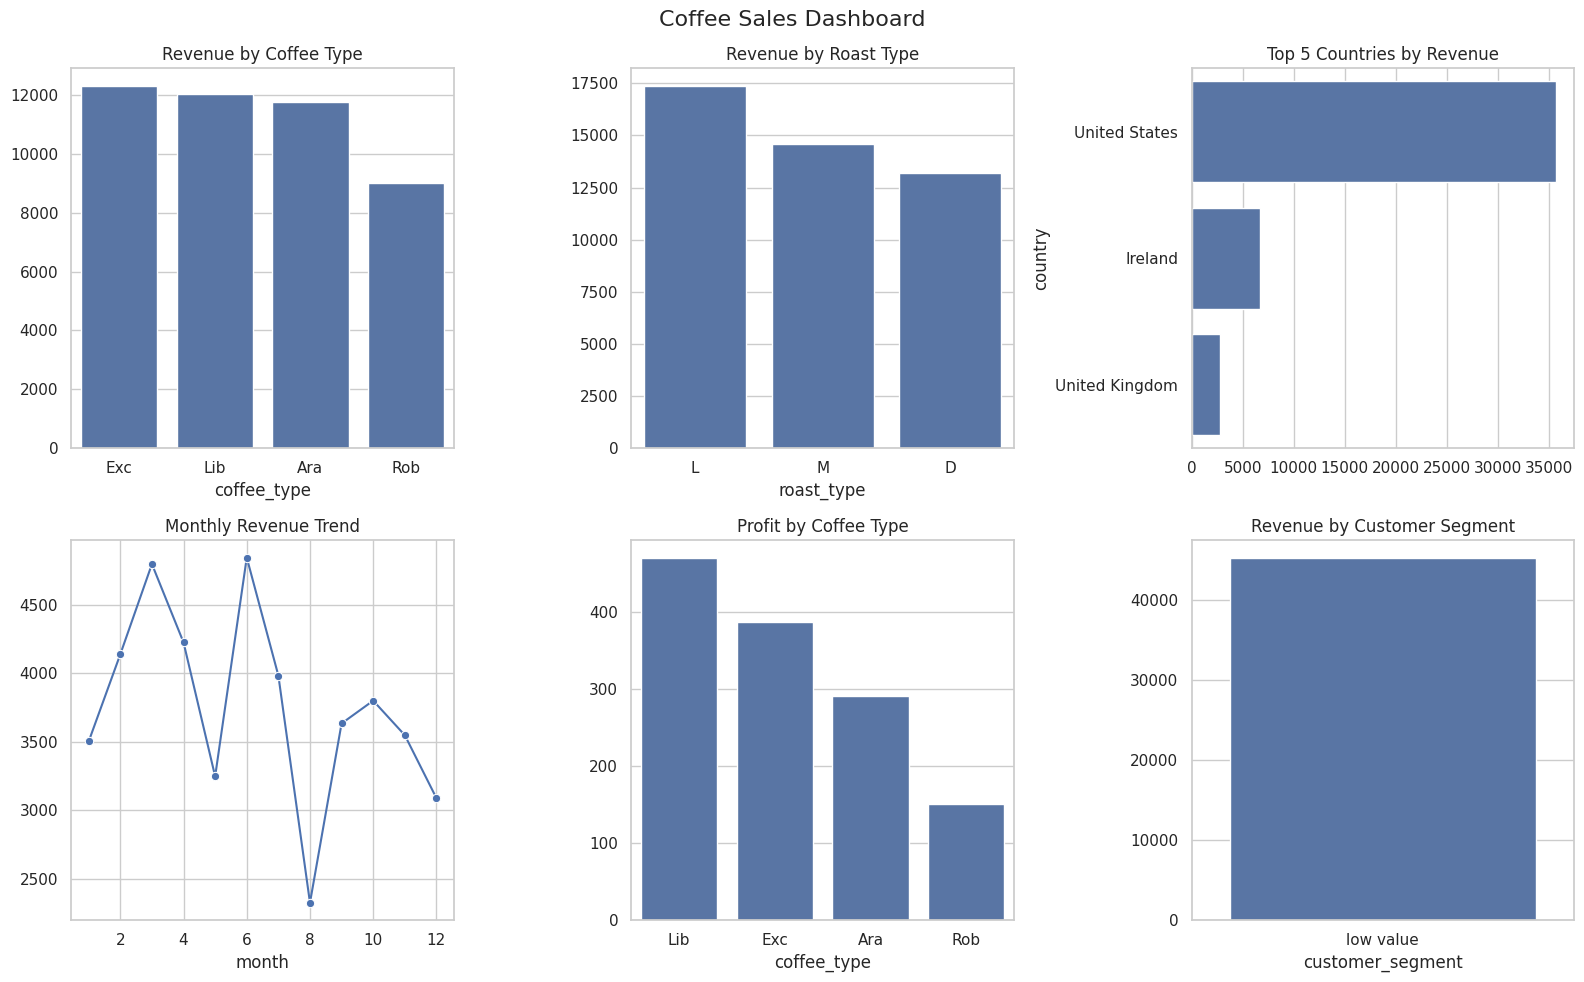

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Create figure
fig = plt.figure(figsize=(16, 10))

# -------------------------------
# 1. Revenue by Coffee Type
# -------------------------------
ax1 = plt.subplot(2, 3, 1)
coffee_rev = df.groupby('coffee_type')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=coffee_rev.index, y=coffee_rev.values, ax=ax1)
ax1.set_title("Revenue by Coffee Type")

# -------------------------------
# 2. Revenue by Roast Type
# -------------------------------
ax2 = plt.subplot(2, 3, 2)
roast_rev = df.groupby('roast_type')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=roast_rev.index, y=roast_rev.values, ax=ax2)
ax2.set_title("Revenue by Roast Type")

# -------------------------------
# 3. Top 5 Countries
# -------------------------------
ax3 = plt.subplot(2, 3, 3)
top_countries = df.groupby('country')['revenue'].sum().nlargest(5)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax3)
ax3.set_title("Top 5 Countries by Revenue")

# -------------------------------
# 4. Monthly Revenue Trend
# -------------------------------
ax4 = plt.subplot(2, 3, 4)
monthly_rev = df.groupby('month')['revenue'].sum()
sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, marker='o', ax=ax4)
ax4.set_title("Monthly Revenue Trend")

# -------------------------------
# 5. Profit by Coffee Type
# -------------------------------
ax5 = plt.subplot(2, 3, 5)
profit = df.groupby('coffee_type')['profit'].sum().sort_values(ascending=False)
sns.barplot(x=profit.index, y=profit.values, ax=ax5)
ax5.set_title("Profit by Coffee Type")

# -------------------------------
# 6. Revenue by Customer Segment
# -------------------------------
ax6 = plt.subplot(2, 3, 6)
segment = df.groupby('customer_segment')['revenue'].sum()
sns.barplot(x=segment.index, y=segment.values, ax=ax6)
ax6.set_title("Revenue by Customer Segment")

# Layout
plt.suptitle("Coffee Sales Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

In [82]:
plt.savefig("coffee_sales_dashboard.png", dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [83]:
sns.set_palette("coolwarm")
sns.set_palette("viridis")

In [84]:
plt.suptitle(
    "Coffee Sales Performance Dashboard\nRevenue, Profit & Customer Insights",
    fontsize=20,
    fontweight='bold'
)

Text(0.5, 0.98, 'Coffee Sales Performance Dashboard\nRevenue, Profit & Customer Insights')

<Figure size 640x480 with 0 Axes>

In [85]:
plt.subplots_adjust(top=0.88)

<Figure size 640x480 with 0 Axes>

In [86]:
plt.suptitle(
    "Coffee Sales Performance Dashboard\nRevenue, Profit & Customer Insights",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.subplots_adjust(top=0.88)

plt.savefig("coffee_sales_dashboard.png", dpi=300, bbox_inches='tight')

plt.show()

<Figure size 640x480 with 0 Axes>

In [87]:
"Coffee Sales Dashboard: Key Business Insights & Trends"

'Coffee Sales Dashboard: Key Business Insights & Trends'

In [88]:
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go

# Create subplots (2 rows x 3 cols)
fig = sp.make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "Revenue by Coffee Type",
        "Revenue by Roast Type",
        "Top 5 Countries",
        "Monthly Revenue Trend",
        "Profit by Coffee Type",
        "Revenue by Customer Segment"
    )
)

# 1. Coffee Type Revenue
coffee_rev = df.groupby('coffee_type')['revenue'].sum().sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=coffee_rev.index, y=coffee_rev.values, name="Coffee Type"),
    row=1, col=1
)

# 2. Roast Type Revenue
roast_rev = df.groupby('roast_type')['revenue'].sum().sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=roast_rev.index, y=roast_rev.values, name="Roast Type"),
    row=1, col=2
)

# 3. Top Countries
top_countries = df.groupby('country')['revenue'].sum().nlargest(5)
fig.add_trace(
    go.Bar(x=top_countries.values, y=top_countries.index, orientation='h'),
    row=1, col=3
)

# 4. Monthly Trend
monthly_rev = df.groupby('month')['revenue'].sum().sort_index()
fig.add_trace(
    go.Scatter(x=monthly_rev.index, y=monthly_rev.values, mode='lines+markers'),
    row=2, col=1
)

# 5. Profit by Coffee Type
profit = df.groupby('coffee_type')['profit'].sum().sort_values(ascending=False)
fig.add_trace(
    go.Bar(x=profit.index, y=profit.values),
    row=2, col=2
)

# 6. Customer Segment
segment = df.groupby('customer_segment')['revenue'].sum()
fig.add_trace(
    go.Bar(x=segment.index, y=segment.values),
    row=2, col=3
)

# Layout (🔥 THIS IS THE MAGIC)
fig.update_layout(
    title={
        'text': "☕ Coffee Sales Performance Dashboard<br><sup>Revenue, Profit & Customer Insights</sup>",
        'x': 0.5,
        'xanchor': 'center'
    },
    template='plotly_dark',  # 🔥 Beautiful dark background
    height=700,
    showlegend=False
)

fig.show()

In [89]:
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go

# -----------------------
# KPIs
# -----------------------
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['quantity'].sum()

# -----------------------
# Create Subplots
# -----------------------
fig = sp.make_subplots(
    rows=3, cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(
        "Total Revenue", "Total Profit", "Total Orders",
        "Revenue by Coffee Type", "Revenue by Roast Type", "Top Countries",
        "Monthly Trend", "Profit by Coffee Type", "Customer Segments"
    )
)

# -----------------------
# KPI Indicators
# -----------------------
fig.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    title={"text": "Revenue"}
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_profit,
    title={"text": "Profit"}
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_orders,
    title={"text": "Orders"}
), row=1, col=3)

# -----------------------
# Charts
# -----------------------
coffee_rev = df.groupby('coffee_type')['revenue'].sum()
fig.add_trace(go.Bar(x=coffee_rev.index, y=coffee_rev.values), row=2, col=1)

roast_rev = df.groupby('roast_type')['revenue'].sum()
fig.add_trace(go.Bar(x=roast_rev.index, y=roast_rev.values), row=2, col=2)

top_countries = df.groupby('country')['revenue'].sum().nlargest(5)
fig.add_trace(go.Bar(x=top_countries.values, y=top_countries.index, orientation='h'), row=2, col=3)

monthly_rev = df.groupby('month')['revenue'].sum().sort_index()
fig.add_trace(go.Scatter(x=monthly_rev.index, y=monthly_rev.values, mode='lines+markers'), row=3, col=1)

profit = df.groupby('coffee_type')['profit'].sum()
fig.add_trace(go.Bar(x=profit.index, y=profit.values), row=3, col=2)

segment = df.groupby('customer_segment')['revenue'].sum()
fig.add_trace(go.Bar(x=segment.index, y=segment.values), row=3, col=3)

# -----------------------
# Layout Styling
# -----------------------
fig.update_layout(
    title={
        'text': "Coffee Sales Executive Dashboard<br><sup>Interactive Business Insights</sup>",
        'x': 0.7
    },
    template="plotly_dark",
    height=900,
    showlegend=False
)

fig.show()

In [90]:
import plotly.subplots as sp
import plotly.graph_objects as go

# -----------------------
# KPIs
# -----------------------
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['quantity'].sum()

# -----------------------
# Create Subplots
# -----------------------
fig = sp.make_subplots(
    rows=3, cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(
        "Total Revenue", "Total Profit", "Total Orders",
        "Revenue by Coffee Type", "Revenue by Roast Type", "Top Countries",
        "Monthly Trend", "Profit by Coffee Type", "Customer Segments"
    )
)

# -----------------------
# KPI Indicators
# -----------------------
fig.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    title={"text": "Revenue"},
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_profit,
    title={"text": "Profit"},
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_orders,
    title={"text": "Orders"},
), row=1, col=3)

# -----------------------
# Charts
# -----------------------
coffee_rev = df.groupby('coffee_type')['revenue'].sum()
fig.add_trace(go.Bar(x=coffee_rev.index, y=coffee_rev.values), row=2, col=1)

roast_rev = df.groupby('roast_type')['revenue'].sum()
fig.add_trace(go.Bar(x=roast_rev.index, y=roast_rev.values), row=2, col=2)

top_countries = df.groupby('country')['revenue'].sum().nlargest(5)
fig.add_trace(go.Bar(x=top_countries.values, y=top_countries.index, orientation='h'), row=2, col=3)

monthly_rev = df.groupby('month')['revenue'].sum().sort_index()
fig.add_trace(go.Scatter(x=monthly_rev.index, y=monthly_rev.values, mode='lines+markers'), row=3, col=1)

profit = df.groupby('coffee_type')['profit'].sum()
fig.add_trace(go.Bar(x=profit.index, y=profit.values), row=3, col=2)

segment = df.groupby('customer_segment')['revenue'].sum()
fig.add_trace(go.Bar(x=segment.index, y=segment.values), row=3, col=3)

# -----------------------
# FINAL LAYOUT (TITLE UPDATED ONLY)
# -----------------------
fig.update_layout(
    title={
        'text': "☕ Coffee Sales Executive Dashboard<br><sup>Interactive Business Insights</sup>",
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=34, family="Arial Black", color="white")  # Bigger title only
    },
    template="plotly_dark",
    height=900,
    showlegend=False
)

# -----------------------
# SHOW DASHBOARD
# -----------------------
fig.show()

In [91]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 3.6 MB/s eta 0:00:00


After uploading the file, you can re-run the dashboard creation cell (`821h5Fzt38W6`) to see the logo appear.

In [92]:
import plotly.subplots as sp
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# -----------------------
# KPIs
# -----------------------
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['quantity'].sum()

# -----------------------
# FORECAST PREPARATION
# -----------------------
monthly_rev = df.groupby('month')['revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('month')

X = monthly_rev[['month']]
y = monthly_rev['revenue']

model = LinearRegression()
model.fit(X, y)

# Predict next 3 months
future_months = np.array([[13], [14], [15]])
forecast_values = model.predict(future_months)

forecast_df = pd.DataFrame({
    'month': [13, 14, 15],
    'revenue': forecast_values
})

# -----------------------
# CREATE SUBPLOTS
# -----------------------
fig = sp.make_subplots(
    rows=3, cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(
        "Total Revenue", "Total Profit", "Total Orders",
        "Revenue by Coffee Type", "Revenue by Roast Type", "Top Countries",
        "Monthly Trend & Forecast", "Profit by Coffee Type", "Customer Segments"
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# -----------------------
# KPI INDICATORS
# -----------------------
fig.add_trace(go.Indicator(
    mode="number",
    value=total_revenue,
    title={"text": "Revenue", "font": {"size": 18}},
    number={"font": {"size": 42}}
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_profit,
    title={"text": "Profit", "font": {"size": 18}},
    number={"font": {"size": 42}}
), row=1, col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_orders,
    title={"text": "Orders", "font": {"size": 18}},
    number={"font": {"size": 42}}
), row=1, col=3)

# -----------------------
# CHARTS
# -----------------------
coffee_rev = df.groupby('coffee_type')['revenue'].sum()
fig.add_trace(go.Bar(x=coffee_rev.index, y=coffee_rev.values), row=2, col=1)

roast_rev = df.groupby('roast_type')['revenue'].sum()
fig.add_trace(go.Bar(x=roast_rev.index, y=roast_rev.values), row=2, col=2)

top_countries = df.groupby('country')['revenue'].sum().nlargest(5)
fig.add_trace(go.Bar(x=top_countries.values, y=top_countries.index, orientation='h'), row=2, col=3)

# -----------------------
# MONTHLY + FORECAST
# -----------------------
fig.add_trace(go.Scatter(
    x=monthly_rev['month'],
    y=monthly_rev['revenue'],
    mode='lines+markers',
    name='Actual'
), row=3, col=1)

fig.add_trace(go.Scatter(
    x=forecast_df['month'],
    y=forecast_df['revenue'],
    mode='lines+markers',
    line=dict(dash='dash'),
    name='Forecast'
), row=3, col=1)

# Profit
profit = df.groupby('coffee_type')['profit'].sum()
fig.add_trace(go.Bar(x=profit.index, y=profit.values), row=3, col=2)

# Customer segment
segment = df.groupby('customer_segment')['revenue'].sum()
fig.add_trace(go.Bar(x=segment.index, y=segment.values), row=3, col=3)

# -----------------------
# LAYOUT (LINKEDIN READY)
# -----------------------
fig.update_layout(
    title={
        'text': "Coffee Sales Executive Dashboard<br><sup>With Forecasting Insights</sup>",
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=36, family="Arial Black", color="white")
    },
    template="plotly_dark",
    height=1000,
    width=1600,
    font=dict(size=16),
    margin=dict(t=120, l=50, r=50, b=50),
    showlegend=True
)


# -----------------------
# SHOW
# -----------------------
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [93]:
import plotly.subplots as sp
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# -----------------------
# KPIs
# -----------------------
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['quantity'].sum()

# -----------------------
# FORECAST PREPARATION
# -----------------------
monthly_rev = df.groupby('month')['revenue'].sum().reset_index().sort_values('month')

X = monthly_rev[['month']]
y = monthly_rev['revenue']

model = LinearRegression()
model.fit(X, y)

future_months = np.array([[13], [14], [15]])
forecast_values = model.predict(future_months)

forecast_df = pd.DataFrame({
    'month': [13, 14, 15],
    'revenue': forecast_values
})

# -----------------------
# CREATE SUBPLOTS
# -----------------------
fig = sp.make_subplots(
    rows=3, cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]],
    subplot_titles=(
        "Total Revenue", "Total Profit", "Total Orders",
        "Revenue by Coffee Type", "Revenue by Roast Type", "Top Countries",
        "Monthly Trend & Forecast", "Profit by Coffee Type", "Customer Segments"
    )
)

# -----------------------
# KPI INDICATORS
# -----------------------
fig.add_trace(go.Indicator(mode="number", value=total_revenue, title={"text": "Revenue"}), row=1, col=1)
fig.add_trace(go.Indicator(mode="number", value=total_profit, title={"text": "Profit"}), row=1, col=2)
fig.add_trace(go.Indicator(mode="number", value=total_orders, title={"text": "Orders"}), row=1, col=3)

# -----------------------
# CHARTS (WITH CLEAN LEGENDS)
# -----------------------
coffee_rev = df.groupby('coffee_type')['revenue'].sum()
fig.add_trace(go.Bar(x=coffee_rev.index, y=coffee_rev.values, name="Coffee Revenue"), row=2, col=1)

roast_rev = df.groupby('roast_type')['revenue'].sum()
fig.add_trace(go.Bar(x=roast_rev.index, y=roast_rev.values, name="Roast Revenue"), row=2, col=2)

top_countries = df.groupby('country')['revenue'].sum().nlargest(5)
fig.add_trace(go.Bar(x=top_countries.values, y=top_countries.index, orientation='h', name="Top Countries"), row=2, col=3)

# -----------------------
# MONTHLY + FORECAST
# -----------------------
fig.add_trace(go.Scatter(
    x=monthly_rev['month'],
    y=monthly_rev['revenue'],
    mode='lines+markers',
    name='Actual Sales'
), row=3, col=1)

fig.add_trace(go.Scatter(
    x=forecast_df['month'],
    y=forecast_df['revenue'],
    mode='lines+markers',
    line=dict(dash='dash'),
    name='Forecast Sales'
), row=3, col=1)

# -----------------------
# ADD FORECAST LABEL
# -----------------------
fig.add_annotation(
    text="Forecast (Next 3 Months)",
    x=14,
    y=forecast_df['revenue'].mean(),
    showarrow=False,
    font=dict(size=12, color="white")
)

# -----------------------
# OTHER CHARTS
# -----------------------
profit = df.groupby('coffee_type')['profit'].sum()
fig.add_trace(go.Bar(x=profit.index, y=profit.values, name="Profit by Coffee"), row=3, col=2)

segment = df.groupby('customer_segment')['revenue'].sum()
fig.add_trace(go.Bar(x=segment.index, y=segment.values, name="Customer Segments"), row=3, col=3)

# -----------------------
# LAYOUT (CLEAN + PROFESSIONAL)
# -----------------------
fig.update_layout(
    title={
        'text': "Coffee Sales Dashboard<br><sup>Performance Analysis & Forecasting</sup>",
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=34, family="Arial Black", color="white")
    },
    template="plotly_dark",
    height=1000,
    width=1600,
    font=dict(size=16),
    margin=dict(t=120, l=50, r=50, b=50),
    showlegend=True
)



# -----------------------
# SHOW
# -----------------------
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [94]:
import plotly.subplots as sp
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# -----------------------
# KPIs
# -----------------------
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['quantity'].sum()

# -----------------------
# FORECAST PREPARATION
# -----------------------
monthly_rev = df.groupby('month')['revenue'].sum().reset_index().sort_values('month')

X = monthly_rev[['month']]
y = monthly_rev['revenue']

model = LinearRegression()
model.fit(X, y)

future_months = np.array([[13], [14], [15]])
forecast_values = model.predict(future_months)

forecast_df = pd.DataFrame({
    'month': [13, 14, 15],
    'revenue': forecast_values
})

# -----------------------
# COUNTRY DATA FOR MAP
# -----------------------
country_rev = df.groupby('country')['revenue'].sum().reset_index()

# -----------------------
# CREATE SUBPLOTS
# -----------------------
fig = sp.make_subplots(
    rows=3, cols=3,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "xy"}, {"type": "xy"}, {"type": "choropleth"}],
        [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=(
        "Total Revenue", "Total Profit", "Total Orders",
        "Revenue by Coffee Type", "Revenue by Roast Type", "Revenue by Country",
        "Monthly Trend & Forecast", "Profit by Coffee Type", "Customer Segments"
    )
)

# -----------------------
# KPI INDICATORS (CLEAN)
# -----------------------
fig.add_trace(go.Indicator(mode="number", value=total_revenue, title={"text": "Revenue"}), row=1, col=1)
fig.add_trace(go.Indicator(mode="number", value=total_profit, title={"text": "Profit"}), row=1, col=2)
fig.add_trace(go.Indicator(mode="number", value=total_orders, title={"text": "Orders"}), row=1, col=3)

# -----------------------
# CHARTS
# -----------------------
coffee_rev = df.groupby('coffee_type')['revenue'].sum()
fig.add_trace(go.Bar(x=coffee_rev.index, y=coffee_rev.values, name="Coffee Revenue"), row=2, col=1)

roast_rev = df.groupby('roast_type')['revenue'].sum()
fig.add_trace(go.Bar(x=roast_rev.index, y=roast_rev.values, name="Roast Revenue"), row=2, col=2)

# -----------------------
# MAP (Revenue by Country)
# -----------------------
fig.add_trace(go.Choropleth(
    locations=country_rev['country'],
    locationmode='country names',
    z=country_rev['revenue'],
    colorscale='Viridis',
    colorbar_title="Revenue"
), row=2, col=3)

# -----------------------
# MONTHLY + FORECAST
# -----------------------
fig.add_trace(go.Scatter(
    x=monthly_rev['month'],
    y=monthly_rev['revenue'],
    mode='lines+markers',
    name='Actual Sales'
), row=3, col=1)

fig.add_trace(go.Scatter(
    x=forecast_df['month'],
    y=forecast_df['revenue'],
    mode='lines+markers',
    line=dict(dash='dash'),
    name='Forecast Sales'
), row=3, col=1)

# -----------------------
# PROFIT
# -----------------------
profit = df.groupby('coffee_type')['profit'].sum()
fig.add_trace(go.Bar(x=profit.index, y=profit.values, name="Profit"), row=3, col=2)

# -----------------------
# CUSTOMER SEGMENT
# -----------------------
segment = df.groupby('customer_segment')['revenue'].sum()
fig.add_trace(go.Bar(x=segment.index, y=segment.values, name="Customer Segments"), row=3, col=3)

# -----------------------
# FORECAST LABEL
# -----------------------
fig.add_annotation(
    text="Forecast (Next 3 Months)",
    x=14,
    y=forecast_df['revenue'].mean(),
    showarrow=False,
    font=dict(size=12, color="white")
)

# -----------------------
# LAYOUT
# -----------------------
fig.update_layout(
    title={
        'text': "<b>☕ Coffee Sales Executive Dashboard</b><br>"
                "<span style='font-size:16px; color:#AAAAAA;'>Performance Analysis • Forecasting • Business Insights</span>",
        'x': 0.7,
        'xanchor': 'center'
    },
    template="plotly_dark",
    height=1000,
    width=1600,
    font=dict(size=14),
    margin=dict(t=140, l=50, r=50, b=50),
    showlegend=True,

    # Map styling
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular'
    )
)


# -----------------------
# SHOW
# -----------------------
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [95]:
import plotly.subplots as sp
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# -----------------------
# KPIs
# -----------------------
total_revenue = df['revenue'].sum()
total_profit = df['profit'].sum()
total_orders = df['quantity'].sum()

# -----------------------
# FORECAST PREPARATION
# -----------------------
monthly_rev = df.groupby('month')['revenue'].sum().reset_index().sort_values('month')

X = monthly_rev[['month']]
y = monthly_rev['revenue']

model = LinearRegression()
model.fit(X, y)

future_months = np.array([[13], [14], [15]])
forecast_values = model.predict(future_months)

forecast_df = pd.DataFrame({
    'month': [13, 14, 15],
    'revenue': forecast_values
})

# -----------------------
# COUNTRY DATA
# -----------------------
country_rev = df.groupby('country')['revenue'].sum().reset_index()

# -----------------------
# CREATE SUBPLOTS
# -----------------------
fig = sp.make_subplots(
    rows=3, cols=3,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "xy"}, {"type": "xy"}, {"type": "choropleth"}],
        [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=(
        "Total Revenue", "Total Profit", "Total Orders",
        "Revenue by Coffee Type", "Revenue by Roast Type", "Revenue by Country",
        "Monthly Trend & Forecast", "Profit by Coffee Type", "Customer Segments"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# -----------------------
# KPI INDICATORS
# -----------------------
fig.add_trace(go.Indicator(mode="number", value=total_revenue, title={"text": "Revenue"}), row=1, col=1)
fig.add_trace(go.Indicator(mode="number", value=total_profit, title={"text": "Profit"}), row=1, col=2)
fig.add_trace(go.Indicator(mode="number", value=total_orders, title={"text": "Orders"}), row=1, col=3)

# -----------------------
# CHARTS
# -----------------------
coffee_rev = df.groupby('coffee_type')['revenue'].sum()
fig.add_trace(go.Bar(x=coffee_rev.index, y=coffee_rev.values), row=2, col=1)

roast_rev = df.groupby('roast_type')['revenue'].sum()
fig.add_trace(go.Bar(x=roast_rev.index, y=roast_rev.values), row=2, col=2)

# -----------------------
# MAP
# -----------------------
fig.add_trace(go.Choropleth(
    locations=country_rev['country'],
    locationmode='country names',
    z=country_rev['revenue'],
    colorscale='Viridis',
    colorbar=dict(
        title="Revenue",
        thickness=10,
        len=0.5,
        y=0.75
    )
), row=2, col=3)

# -----------------------
# MONTHLY + FORECAST
# -----------------------
fig.add_trace(go.Scatter(
    x=monthly_rev['month'],
    y=monthly_rev['revenue'],
    mode='lines+markers'
), row=3, col=1)

fig.add_trace(go.Scatter(
    x=forecast_df['month'],
    y=forecast_df['revenue'],
    mode='lines+markers',
    line=dict(dash='dash')
), row=3, col=1)

# -----------------------
# PROFIT
# -----------------------
profit = df.groupby('coffee_type')['profit'].sum()
fig.add_trace(go.Bar(x=profit.index, y=profit.values), row=3, col=2)

# -----------------------
# CUSTOMER SEGMENTS
# -----------------------
segment = df.groupby('customer_segment')['revenue'].sum()
fig.add_trace(go.Bar(x=segment.index, y=segment.values), row=3, col=3)

# -----------------------
# FIX AXES (REMOVE NEGATIVE SPACE)
# -----------------------
fig.update_yaxes(rangemode="tozero")

# -----------------------
# FORECAST ANNOTATION
# -----------------------
fig.add_annotation(
    text="Forecast",
    x=14,
    y=max(monthly_rev['revenue']),
    showarrow=True,
    arrowhead=2,
    font=dict(size=12, color="white")
)

# -----------------------
# LAYOUT
# -----------------------
fig.update_layout(
    title={
        'text': "<b>☕ Coffee Sales Dashboard</b><br>"
                "<span style='font-size:16px; color:#AAAAAA;'>Performance Analysis & Forecasting</span>",
        'x': 0.5
    },
    template="plotly_dark",
    height=900,
    width=1400,
    margin=dict(t=120, l=60, r=40, b=50),
    font=dict(size=13),
    showlegend=False
)


# -----------------------
# SHOW
# -----------------------
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

